In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
from tensorflow.keras.optimizers import Adam, Adamax
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
import timeit
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix)
import cv2


2026-03-13 20:03:35.315837: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773432215.506996      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773432215.563333      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773432216.023852      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773432216.023897      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773432216.023903      24 computation_placer.cc:177] computation placer alr

In [2]:
train_data_dir ="/kaggle/input/brain-tumor-mri-datasets/Brain_Tumor_Datasets/train"
test_data_dir="/kaggle/input/brain-tumor-mri-datasets/Brain_Tumor_Datasets/test"

In [3]:
np.random.seed(12049)

In [4]:
import os

def get_classes(data_path, classes, data):


    print(f"---- {data} ----")
    class_images = {}
    total_count = 0

    for folder, label in classes.items():
        folder_path = os.path.join(data_path, folder)
        imgs = os.listdir(folder_path)

        class_images[label] = imgs
        total_count += len(imgs)

    for label, imgs in class_images.items():
        print(
            f"{label}: {len(imgs)} images, {round((len(imgs) * 100) / total_count, 2)}%"
        )

    return class_images


In [5]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

def plot_classes(dict_classes, data_path, classes, data):


   
    label_to_folder = {v: k for k, v in classes.items()}

    for label, img_list in dict_classes.items():
        print(f"{data} - {label}")

        plt.figure(figsize=(12, 4))

        for i in range(min(5, len(img_list))):
            img_path = os.path.join(
                data_path,
                label_to_folder[label],
                img_list[i]
            )

            img = tf.keras.preprocessing.image.load_img(img_path)

            plt.subplot(1, 5, i + 1)
            plt.imshow(img)
            plt.title(label)
            plt.axis("off")

        plt.show()


In [6]:
classes = {
    "no": "No Tumor",    
    "yes": "Tumor"
}

In [7]:
train_data=get_classes(train_data_dir, classes, 'Train')
test_data=get_classes(test_data_dir, classes, 'Test')

---- Train ----
No Tumor: 2869 images, 40.92%
Tumor: 4143 images, 59.08%
---- Test ----
No Tumor: 717 images, 40.92%
Tumor: 1035 images, 59.08%


Train data - No Tumor


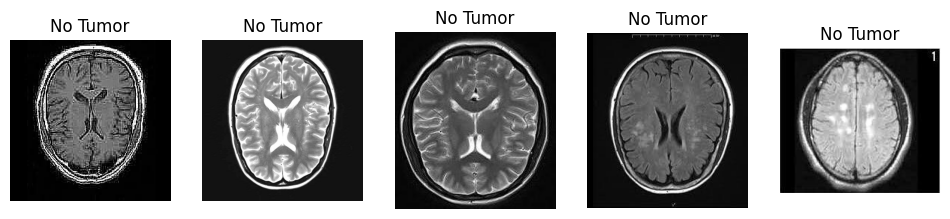

Train data - Tumor


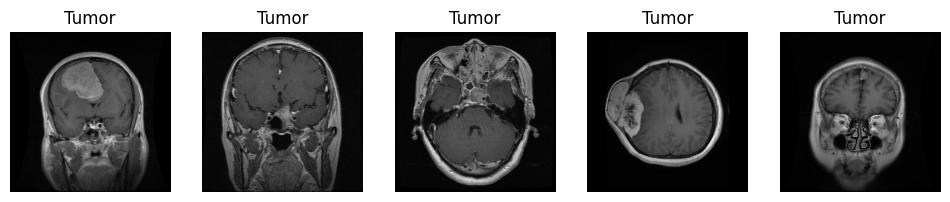

In [8]:
plot_classes(train_data, train_data_dir, classes, 'Train data')

Found 7012 images belonging to 2 classes.


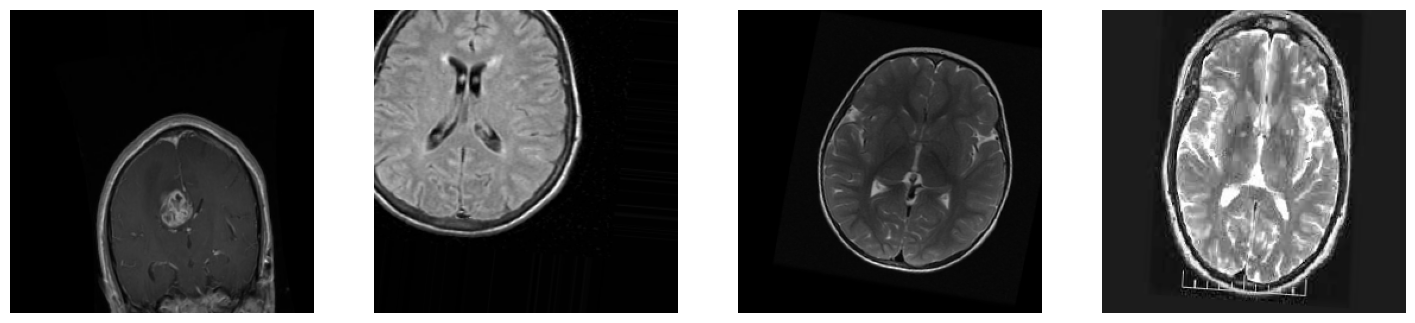

In [9]:
train_gen=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)
test_gen=tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

imagegen = train_gen.flow_from_directory(train_data_dir, batch_size=1)

fig, rows = plt.subplots(1, 4, figsize=(18, 18))
for row in rows:
    img = next(imagegen)[0][0] 
    row.imshow(img)
    row.axis("off")

plt.show()

In [10]:
#load train data
train_aug=train_gen.flow_from_directory(
    train_data_dir,
    target_size=(224,224),
    class_mode='binary',
    shuffle = True,
    color_mode = "rgb",
    subset='training'
)
# load validation data
validation_aug=train_gen.flow_from_directory(
    train_data_dir,
    target_size=(224,224),
    color_mode = "rgb",
    class_mode='binary',
    subset='validation'
)
#load test data
test_aug=test_gen.flow_from_directory(
    test_data_dir,
    target_size=(224,224),
    color_mode = "rgb",
    class_mode='binary',
    shuffle=False
)

Found 5611 images belonging to 2 classes.
Found 1401 images belonging to 2 classes.
Found 1752 images belonging to 2 classes.


In [11]:
y_train = train_aug.labels
y_val = validation_aug.labels

In [12]:
unique, counts = np.unique(y_train, return_counts=True)
print("Train: ", dict(zip(unique, counts)))

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
train_class_weights = dict(enumerate(class_weights))
print(train_class_weights)

Train:  {np.int32(0): np.int64(2296), np.int32(1): np.int64(3315)}
{0: np.float64(1.2219076655052266), 1: np.float64(0.8463046757164404)}


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Dense, Dropout, Flatten
)
#VGG16 with batch normalization

input_shape = (224, 224, 3)  

model = Sequential()


model.add(Conv2D(64, (3,3), padding='same', activation='relu', input_shape=input_shape))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))


model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))


model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))


model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))


model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))


model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773432233.629983      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 512)    │         2,04

 Total params: 134,281,537 (512.24 MB)

 Trainable params: 134,273,089 (512.21 MB)

 Non-trainable params: 8,448 (33.00 KB)

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
start_ft = timeit.default_timer()
history= model.fit(
    train_aug,
    batch_size=64,
    validation_data=validation_aug,
    epochs=20,
    class_weight=train_class_weights,
)
stop_ft = timeit.default_timer()

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1773432244.685682      95 service.cc:152] XLA service 0x7f596c00afe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773432244.685720      95 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773432246.258171      95 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773432269.461269      95 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


176/176 ━━━━━━━━━━━━━━━━━━━━ 154s 687ms/step - accuracy: 0.7068 - loss: 13.7578 - val_accuracy: 0.4083 - val_loss: 2.2202
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 461ms/step - accuracy: 0.8459 - loss: 1.1203 - val_accuracy: 0.6738 - val_loss: 0.7247
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 80s 454ms/step - accuracy: 0.8707 - loss: 0.5135 - val_accuracy: 0.4133 - val_loss: 1.1517
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 457ms/step - accuracy: 0.8448 - loss: 0.7042 - val_accuracy: 0.4604 - val_loss: 15.1429
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 460ms/step - accuracy: 0.8591 - loss: 0.4838 - val_accuracy: 0.4211 - val_loss: 2.0339
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 82s 462ms/step - accuracy: 0.8525 - loss: 0.5807 - val_accuracy: 0.8323 - val_loss: 0.7044
Epoch 7/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 460ms/step - accuracy: 0.8663 - loss: 0.4667 - val_accuracy: 0.4069 - val_loss: 2.1729
Epoch 8/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 82s 464ms/step - accuracy: 0.9010 - loss: 0.3311 - 

In [16]:
execution_time_ft = (stop_ft - start_ft) / 60
print(
    f"Model VGG 16 executed in {execution_time_ft:.2f} minutes"
)

Model VGG 16 executed in 28.47 minutes


In [17]:
test_loss,test_acc=model.evaluate(test_aug)
print(f"Test Accuracy: {test_acc:.2f}")

55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 266ms/step - accuracy: 0.9486 - loss: 0.3084
Test Accuracy: 0.94


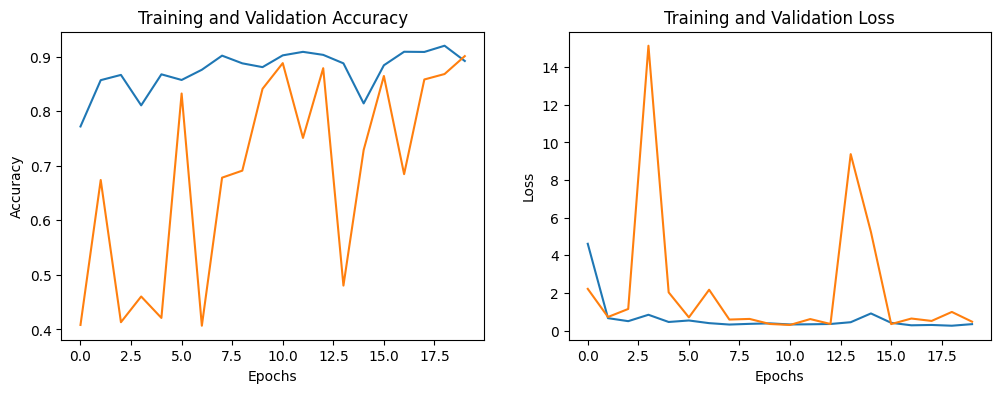

In [18]:
#training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title('Training and Validation Accuracy')
#training and validation loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title('Training and Validation Loss')

plt.show()

In [19]:
predictions= model.predict(test_aug)
prediction_class= np.where(predictions.flatten()>0.5,1,0)
#classification report
print(classification_report(test_aug.classes,prediction_class, target_names=['No Tumor','Tumor'] ))

55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step
              precision    recall  f1-score   support

    No Tumor       0.89      0.97      0.93       717
       Tumor       0.98      0.92      0.95      1035

    accuracy                           0.94      1752
   macro avg       0.93      0.94      0.94      1752
weighted avg       0.94      0.94      0.94      1752



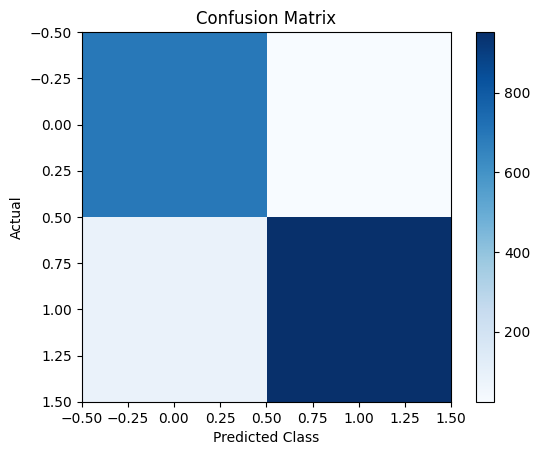

In [20]:
cm= confusion_matrix(test_aug.classes, prediction_class)
#plot the confusion matrix
plt.imshow(cm,cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual")
plt.colorbar()
plt.show()